# **1. Entendimiento del negocio**
En una clínica de ginecobstetricia, en la que se cuenta con la información de 2.126 histogramas a fetos. Se pide construir un modelo de clasificación que sea capaz de determinar si un feto es normal, sospechoso o cuenta con alguna patología cardiaca. El modelo debería contar con un desempeño superior al 85% en accuracy y con la mejor matriz de confusión y f1 score posible.

# **2.Enfoque analítico**

Desarrollar un experimento de clasificación para determinar si un feto es normal, sospechoso o cuenta con alguna patología cardiaca con un desempeño esperado mayor al 85%.

# **3. Recolección de datos**

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

##Importación de los datos
data = pd.read_csv('datos_caso_2.csv')
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sb

# **5. Entendimiento de los datos**

- Análisis de Completitud: calidad de datos
- Análisis Univariado: entender cada variable
- Análisis Bivariado: relaciones simples entre variables
- Análisis Multivariado: relaciones complejas entre más de 2 variables

- Datos nulos
- Desbalance de y (fetal_health)

In [3]:
#Identificación de datos nulos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

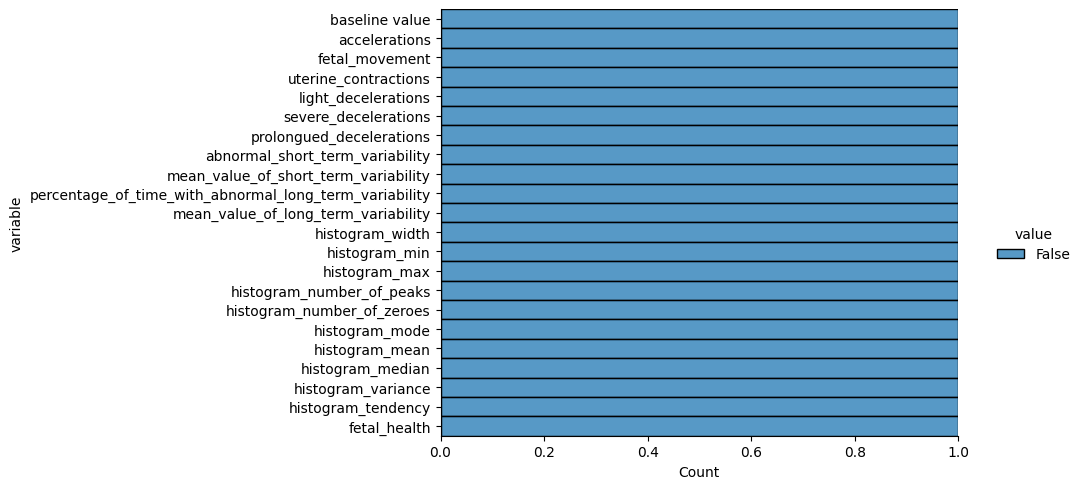

In [4]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', 
                                                hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

Según la información de la gráfica, ninguna variable tiene datos nulos

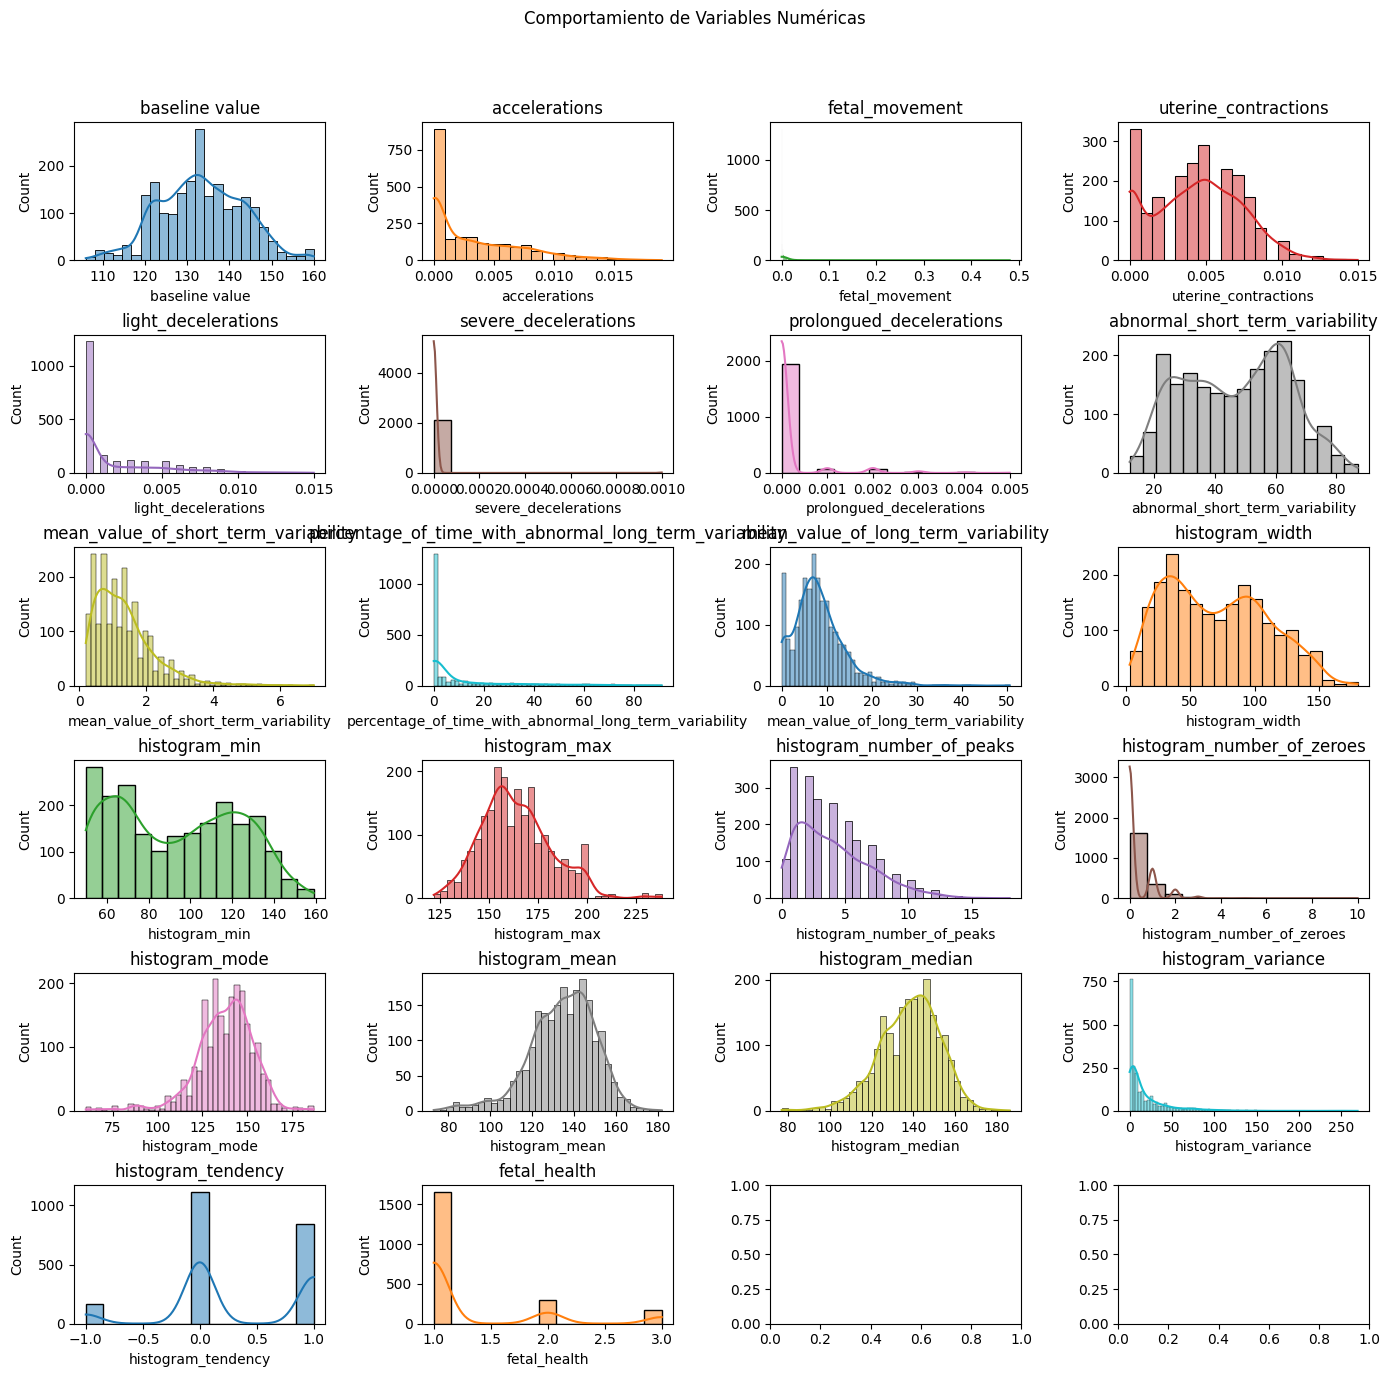

In [5]:
#Exploración univariada de los datos
##Para datos numéricos: histogramas de frecuencia
##Para datos categóricos: gráficos de torta

###HISTOGRAMAS DE FRECUENCIA
fig, ax = plt.subplots(6, 4, figsize = (14, 14))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.histplot(data = data, x = col, 
                kde = True, color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

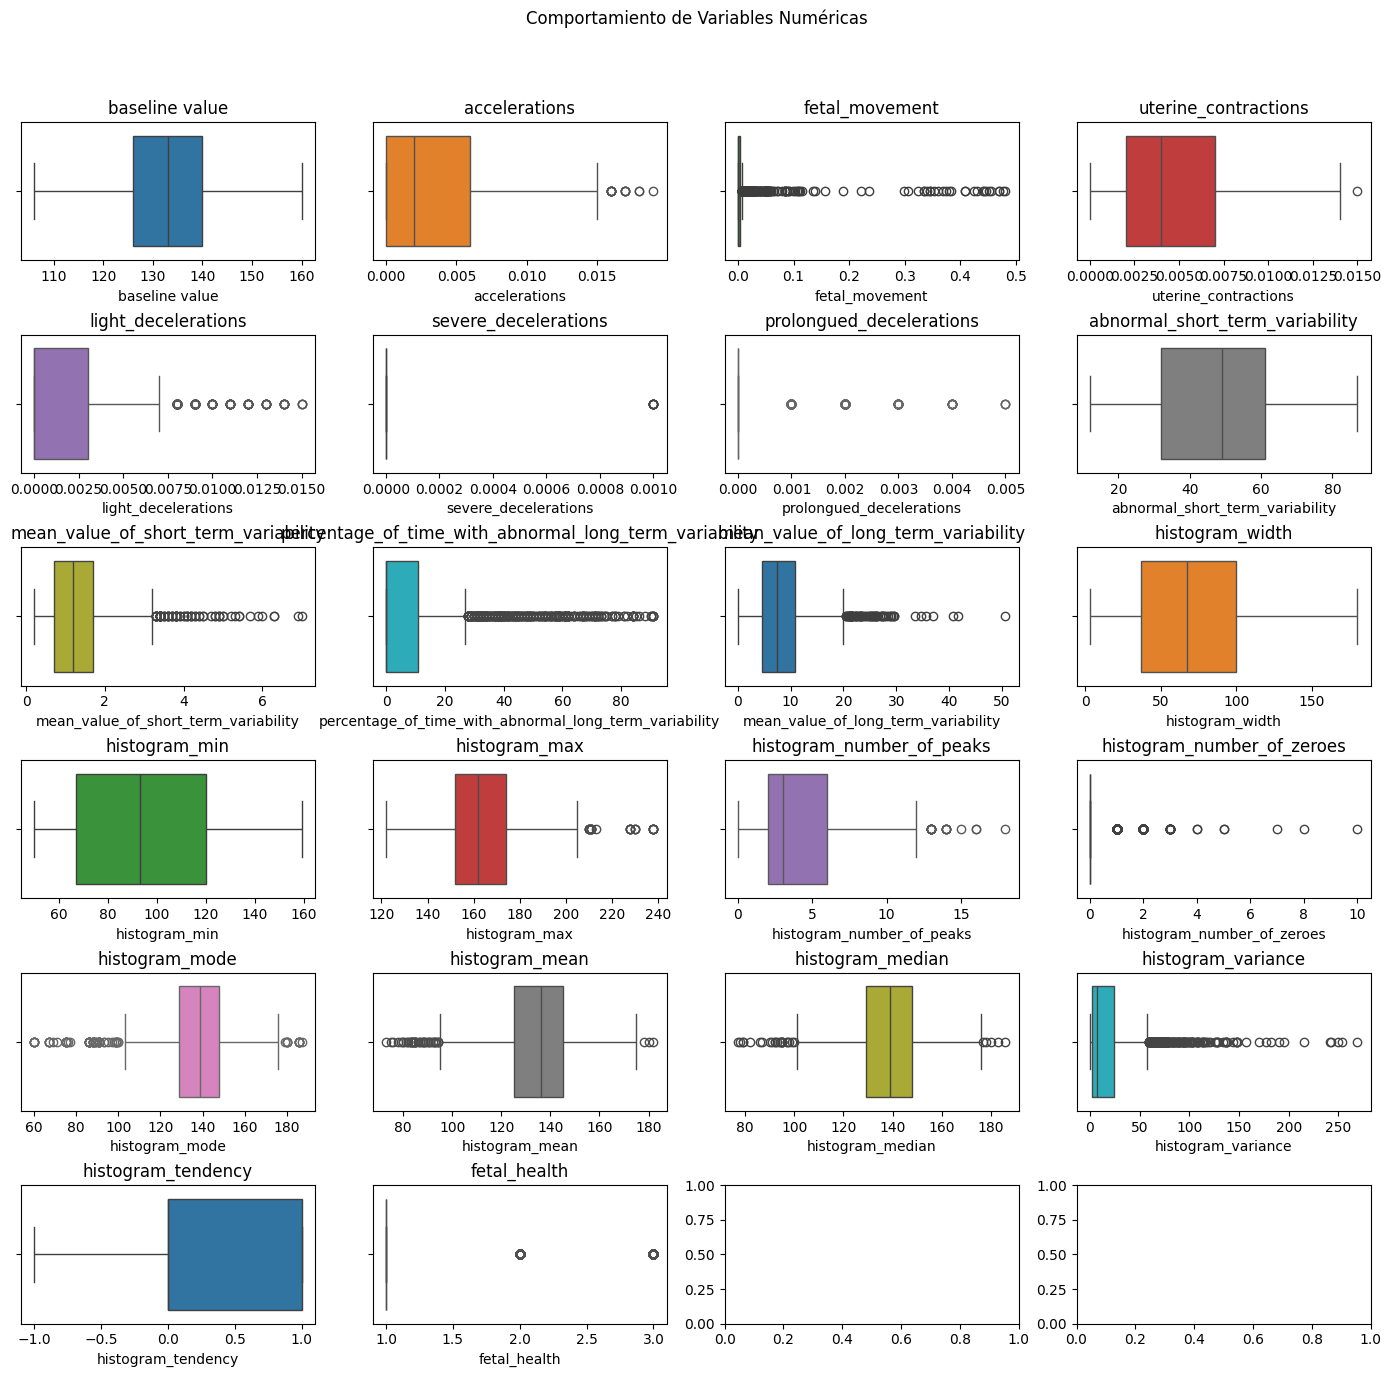

In [6]:
###CAJAS Y BIGOTES
fig, ax = plt.subplots(6, 4, figsize = (14, 14))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.boxplot(data = data, x = col, 
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

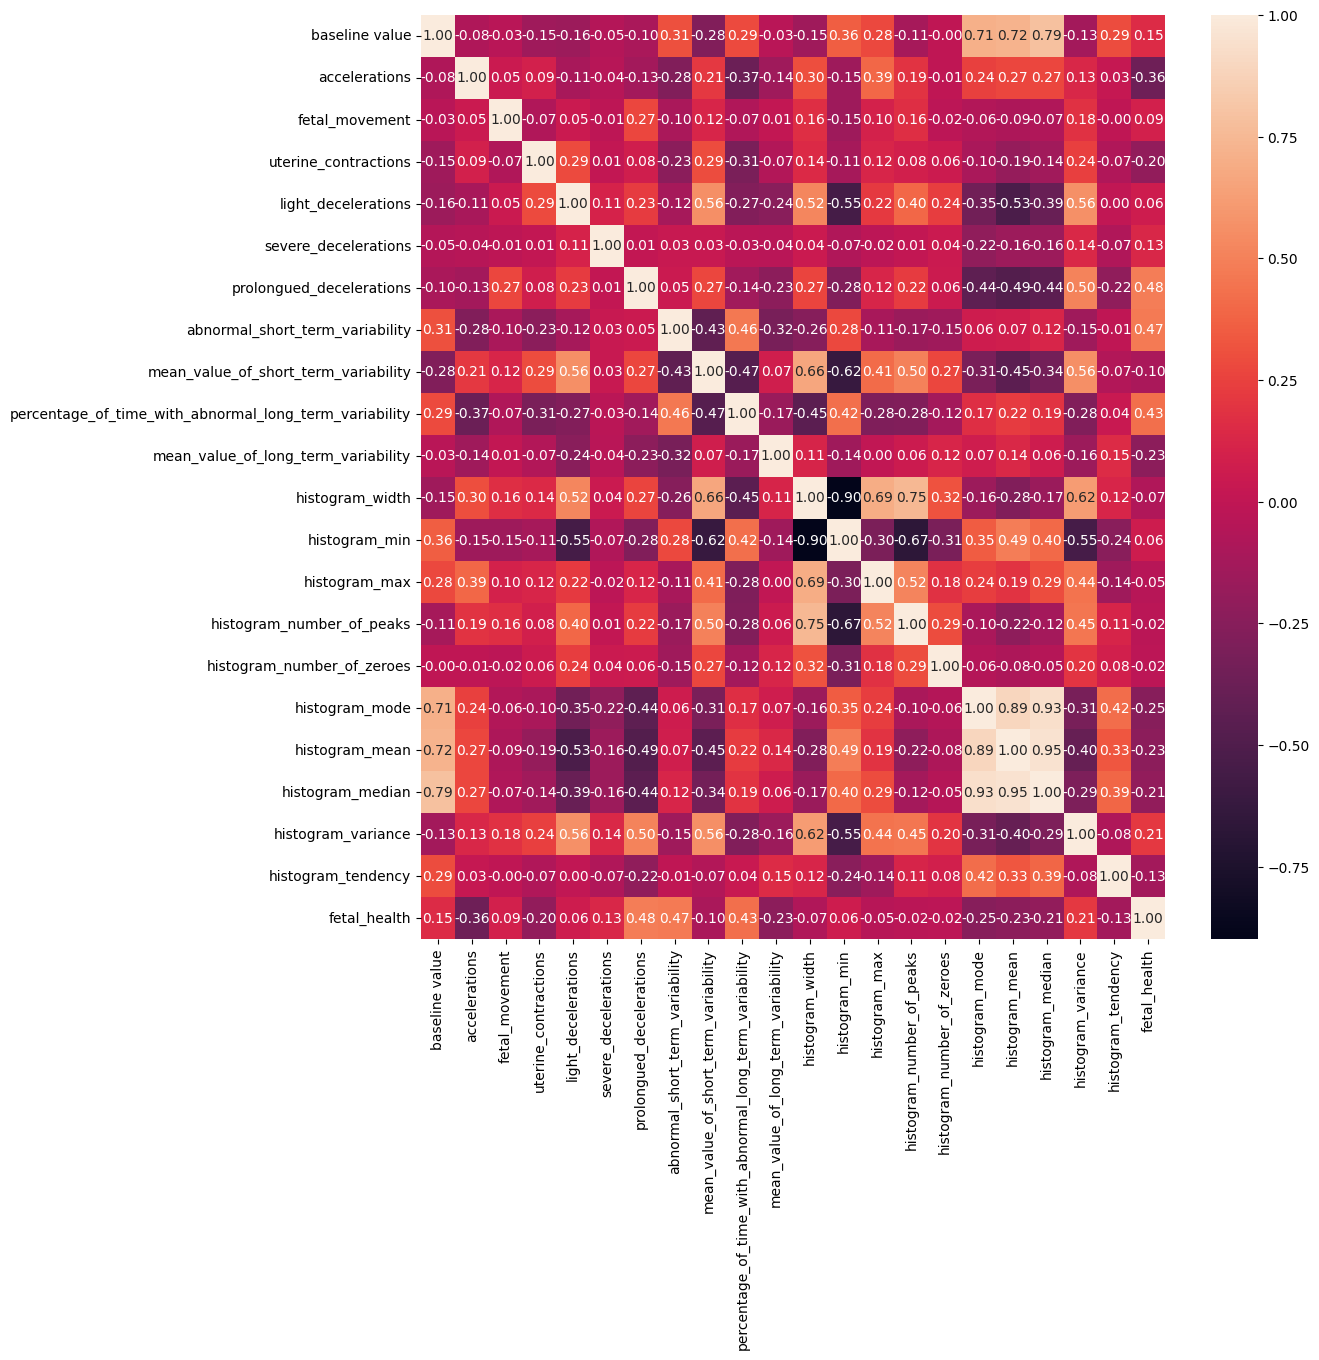

In [7]:
# Mapa de correlación
plt.figure(figsize=(12, 12))
sb.heatmap(data.corr(numeric_only=True), annot = True, fmt = '.2f')
plt.show()

In [8]:
# fetal_movements podría ser ignorada (muy concentrada y muy poca correlación)
# severe_decelerations candidata a eliminar (variable casi constante, poco aporte)

# eliminar histogram_mode y histogram_mean, me quedo con histogram_median (multicolinealidad)
# elimino histogram_width porque es una variable derivada de histogram_min y histogram_max (multicolinealidad)

# histogram_tendency y la Y fetal_health, tratar como categórica

# **6. Preparación de los datos**
- Ignorar las variables poco representativas
- Balancear la variable y (la variable que estoy supervisando, fetal_health, esta desbalanceada)
- Escalar variables numéricas y codificar variables categóricas
- Separar en conjuntos de entrenamiento y validación

In [9]:
# Pasar histogram_tendency a tipo categórico
data['histogram_tendency'] = data['histogram_tendency'].astype('str')

In [10]:
# Se descarta fetal_movements y severe_decelerations por su baja variabilidad, variables muy sesgadas y con poca correlación con y.
data = data.drop(columns = ['fetal_movement', 'severe_decelerations'])

In [11]:
# Se descartan histogram_mode y histogram_mean, conservamos histogram_median (multicolinealidad)
data = data.drop(columns = ['histogram_mode', 'histogram_mean'])

In [12]:
# Se descarta histogram_width porque es una variable derivada de histogram_min y histogram_max, lo que genera redundancia.
data = data.drop(columns = ['histogram_width'])

In [13]:
#BALANCEO DE Y
data_high = data[data['fetal_health'] == 1]
data_medium = data[data['fetal_health'] == 2]
data_low = data[data['fetal_health'] == 3]
print(f'El tamaño de la clase 1 es: {data_high.shape}\nEl tamaño de la clase 2 es: {data_medium.shape}\nEl tamaño de la clase 3 es: {data_low.shape}')

# Se filtra por filas

El tamaño de la clase 1 es: (1655, 17)
El tamaño de la clase 2 es: (295, 17)
El tamaño de la clase 3 es: (176, 17)


In [14]:
# Se realiza oversampling de las clases minoritarias para igualar su tamaño
# al de la clase mayoritaria, permitiendo la repetición de registros 
data_medium_re = data_medium.sample(data_high.shape[0], replace = True)
data_low_re = data_low.sample(data_high.shape[0], replace = True)
data_balanced = pd.concat([data_high, data_medium_re, data_low_re])
data_balanced.reset_index(drop=True, inplace=True)
data_balanced.info()


<class 'pandas.DataFrame'>
RangeIndex: 4965 entries, 0 to 4964
Data columns (total 17 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          4965 non-null   float64
 1   accelerations                                           4965 non-null   float64
 2   uterine_contractions                                    4965 non-null   float64
 3   light_decelerations                                     4965 non-null   float64
 4   prolongued_decelerations                                4965 non-null   float64
 5   abnormal_short_term_variability                         4965 non-null   float64
 6   mean_value_of_short_term_variability                    4965 non-null   float64
 7   percentage_of_time_with_abnormal_long_term_variability  4965 non-null   float64
 8   mean_value_of_long_term_variability              

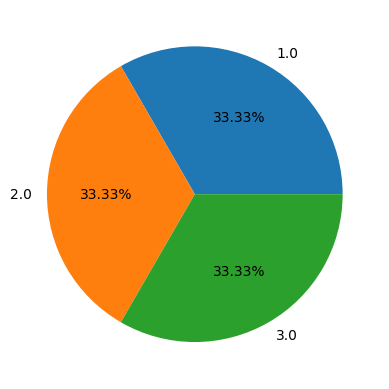

In [15]:
plt.pie(x = data_balanced.fetal_health.value_counts(), labels = data_balanced.fetal_health.value_counts().index, autopct = '%0.2f%%')
plt.show()

In [16]:
# Separar X y Y
X = data_balanced.drop('fetal_health', axis = 1)
y = data_balanced[['fetal_health']]
print(f'El tamaño de X es: {X.shape} y el tamaño de y es: {y.shape}')

El tamaño de X es: (4965, 16) y el tamaño de y es: (4965, 1)


In [17]:
# Transformar X
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

num_col = X.select_dtypes(include = ['int64', 'float64']).columns.to_list()
cat_col = X.select_dtypes(include = ['object']).columns.to_list()
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder(sparse_output = False))])
preprocessor = ColumnTransformer(transformers = [('num', num_transformer, num_col),
                                                 ('cat', cat_transformer, cat_col)],
                                                 remainder = 'passthrough')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [18]:
X_pre = preprocessor.fit_transform(X)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])
X_pro = pd.DataFrame(X_pre, columns = labels)
X_pro.head(10)

,baseline value,accelerations,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_median,histogram_variance,histogram_tendency_-1.0,histogram_tendency_0.0,histogram_tendency_1.0
0,0.481481,0.315789,0.400000,0.200000,0.0,0.066667,0.279412,0.0,0.205128,0.165138,0.655172,0.333333,0.1,0.577982,0.044610,0.0,1.0,0.0
1,0.500000,0.157895,0.533333,0.200000,0.0,0.053333,0.279412,0.0,0.264300,0.165138,0.655172,0.277778,0.1,0.559633,0.048327,0.0,1.0,0.0
2,0.518519,0.157895,0.533333,0.200000,0.0,0.053333,0.323529,0.0,0.453649,0.027523,0.413793,0.611111,0.0,0.550459,0.048327,0.0,0.0,1.0
3,0.481481,0.368421,0.533333,0.000000,0.0,0.053333,0.323529,0.0,0.392505,0.027523,0.413793,0.500000,0.0,0.559633,0.040892,0.0,0.0,1.0
4,0.462963,0.263158,0.533333,0.200000,0.0,0.213333,0.176471,0.0,0.254438,0.348624,0.275862,0.277778,0.0,0.550459,0.026022,0.0,0.0,1.0
5,0.462963,0.473684,0.400000,0.133333,0.0,0.213333,0.191176,0.0,0.106509,0.192661,0.310345,0.111111,0.0,0.587156,0.037175,0.0,0.0,1.0
6,0.444444,0.315789,0.266667,0.333333,0.2,0.120000,0.308824,0.0,0.155819,0.155963,0.448276,0.388889,0.0,0.532110,0.282528,0.0,1.0,0.0
7,0.444444,0.315789,0.266667,0.266667,0.2,0.093333,0.308824,0.0,0.171598,0.155963,0.448276,0.166667,0.0,0.513761,0.159851,0.0,1.0,0.0
8,0.444444,0.315789,0.333333,0.333333,0.0,0.160000,0.279412,0.0,0.214990,0.027523,0.482759,0.277778,0.0,0.559633,0.260223,0.0,0.0,1.0
9,0.444444,0.157895,0.400000,0.266667,0.2,0.146667,0.250000,0.0,0.173570,0.082569,0.310345,0.333333,0.0,0.477064,0.133829,0.0,0.0,1.0


In [19]:
# Se separan las X y Y de entrenamiento y validación, con un 70% de entrenamiento
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pro, y, train_size = 0.7, random_state = 123)
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {y_train.shape}\nEl tamaño del conjunto de validación es: {X_test.shape} {y_test.shape}')

El tamaño del conjunto de entrenamiento es: (3475, 18) (3475, 1)
El tamaño del conjunto de validación es: (1490, 18) (1490, 1)


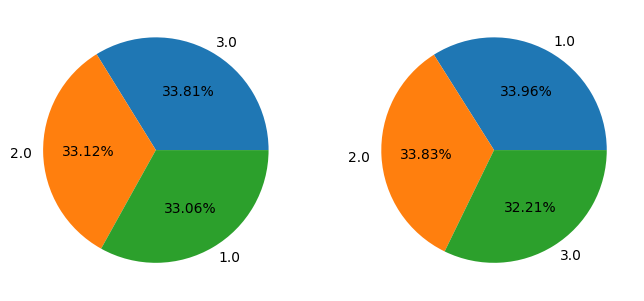

In [20]:
fig, ax = plt.subplots(1, 2, figsize = (8, 8))
ax[0].pie(x = y_train.fetal_health.value_counts(), labels = y_train.fetal_health.value_counts().index, autopct = '%0.2f%%')
ax[1].pie(x = y_test.fetal_health.value_counts(), labels = y_test.fetal_health.value_counts().index, autopct = '%0.2f%%')
plt.show()

# **7. Modelado de Datos**

- Regresión Logística
- K Vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting
- Red Neuronal Artificial

In [21]:
#Regresión Logística
from sklearn.linear_model import LogisticRegression
# Busqueda de hiperparámetros y validación cruzada
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Se define el modelo pero sin hiperparámetros optimos aún
# 'saga' es un tipo específico de solver basado en descenso por gradiente estocástico mejorado
model_1 = LogisticRegression(solver = 'saga', random_state = 123)
# Define todas las combinaciones de hiperparámetros a probar (24 modelos)
param_grid = {'penalty':['l1', 'l2', 'elasticnet'], 'C':[0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}
# Validación cruzada
# Stratified: Mantiene la proporción de clases en cada fold
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
# Se crea el sistema automático para probar muchos modelos y escoger el mejor
clf_1 = GridSearchCV(estimator = model_1, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
# Se ejecuta la combinación de hiperparámetros y cross validation
clf_1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [22]:
# Se construye una tabla con todas las combinaciones de hiperparámetros y su desempeño (F1 promedio)
# clf_1.cv_results_ es un diccionario que guarda todo lo que pasó en Grid Search
validation = pd.concat([pd.DataFrame(clf_1.cv_results_['params']),
                        pd.DataFrame(clf_1.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,C,penalty,F1_score
9,1.000,l1,0.868762
13,10.000,l2,0.868723
14,10.000,elasticnet,0.868723
16,100.000,l2,0.863402
17,100.000,elasticnet,0.863402
12,10.000,l1,0.863400
18,1000.000,l1,0.861917
19,1000.000,l2,0.861917
20,1000.000,elasticnet,0.861917
21,10000.000,l1,0.861917


In [23]:
#K Vecinos Más Cercanos
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier()
# Hiperparámetros a probar (numero de vecinos y tipo de distancia)
param_grid = {'n_neighbors':[3, 5, 9, 7, 11, 15, 101], 'p':[1, 2]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_2 = GridSearchCV(estimator = model_2, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_2.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [24]:
validation = pd.concat([pd.DataFrame(clf_2.cv_results_['params']),
                        pd.DataFrame(clf_2.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,n_neighbors,p,F1_score
0,3,1,0.960716
1,3,2,0.957831
2,5,1,0.942327
3,5,2,0.939466
6,7,1,0.930459
7,7,2,0.927922
5,9,2,0.918907
4,9,1,0.916408
9,11,2,0.911252
8,11,1,0.904370


In [25]:
#Máquina de soporte vectorial
from sklearn.svm import SVC
model_3 = SVC(random_state=123)
# Hiperparámetros a probar (epsilon y kernel)
param_grid = {'C':[0.001, 0.01, 0.1, 10, 100], 'kernel':['poly','linear', 'rbf', 'sigmoid'], 'degree':[2, 3]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_3 = GridSearchCV(estimator = model_3, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_3.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'degree': [2, 3], 'kernel': ['poly', 'linear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

In [26]:
validation = pd.concat([pd.DataFrame(clf_3.cv_results_['params']),
                        pd.DataFrame(clf_3.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,C,degree,kernel,F1_score
36,100.000,3,poly,0.955489
34,100.000,2,rbf,0.952919
38,100.000,3,rbf,0.952919
32,100.000,2,poly,0.941555
28,10.000,3,poly,0.938053
26,10.000,2,rbf,0.931917
30,10.000,3,rbf,0.931917
24,10.000,2,poly,0.922686
33,100.000,2,linear,0.877594
37,100.000,3,linear,0.877594


La profundidad del árbol es: 18
Número de hojas: 134


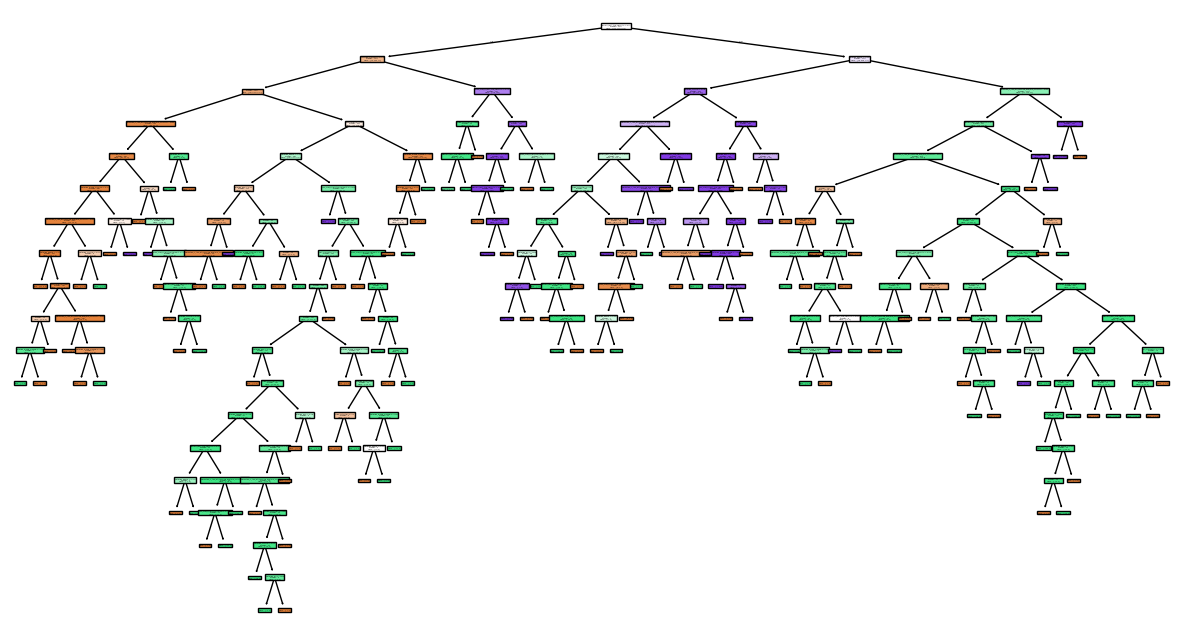

In [27]:
#Árbol de Decisión

# Se crea el arbol de decisión puro, sin hiperparámetros optimos, para visualizar su estructura 
# y decidir cuales hiperparámetros probar en la busqueda de Grid Search
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state = 123)
model_tree.fit(X_train, y_train)
print(f'La profundidad del árbol es: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize = (15, 8))
plot = plot_tree(decision_tree = model_tree, feature_names = labels, filled=True, impurity=False, ax = ax)

In [33]:
model_4 = DecisionTreeClassifier(random_state = 123)
# Hiperparámetros a probar (tipo de impureza, profundidad, numero de hojas y numero mínimo de muestras para dividir un nodo)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12, 14, 16], 
              'max_leaf_nodes':[None, 5, 10, 30, 50, 100, 130], 
              'min_samples_split':[2, 4, 6]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_4 = GridSearchCV(estimator = model_4, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_4.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [35]:
validation = pd.concat([pd.DataFrame(clf_4.cv_results_['params']),
                        pd.DataFrame(clf_4.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,F1_score
420,log_loss,16,NaN,2,0.975110
126,entropy,16,NaN,2,0.975110
438,log_loss,16,130.0,2,0.974516
144,entropy,16,130.0,2,0.974516
273,gini,16,NaN,2,0.974249
...,...,...,...,...,...
4,entropy,3,5.0,4,0.770419
5,entropy,3,5.0,6,0.770419
297,log_loss,3,5.0,2,0.770419
299,log_loss,3,5.0,6,0.770419


MODELOS DE ENSAMBLE

In [36]:
#ExtraTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
model_5 = ExtraTreesClassifier(random_state = 123)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12, 14, 16],
              'max_leaf_nodes':[None, 5, 10, 30, 50, 100, 130], 
              'min_samples_split':[2, 4, 6], 'n_estimators':[100, 200, 400, 500]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_5 = GridSearchCV(estimator = model_5, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_5.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesCla...dom_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- 

In [37]:
validation = pd.concat([pd.DataFrame(clf_5.cv_results_['params']),
                        pd.DataFrame(clf_5.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,F1_score
1681,log_loss,16,NaN,2,200,0.985888
505,entropy,16,NaN,2,200,0.985888
1687,log_loss,16,NaN,4,500,0.985887
511,entropy,16,NaN,4,500,0.985887
1685,log_loss,16,NaN,4,200,0.985886
...,...,...,...,...,...,...
12,entropy,3,5.0,2,100,0.814126
16,entropy,3,5.0,4,100,0.814126
600,gini,3,5.0,2,100,0.809447
608,gini,3,5.0,6,100,0.809447


In [ ]:
#RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
model_6 = RandomForestClassifier(random_state = 123)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12, 14, 16],
              'max_leaf_nodes':[None, 5, 10, 30, 50, 100, 130], 
              'min_samples_split':[2, 4, 6], 'n_estimators':[100, 200, 400, 500]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_6 = GridSearchCV(estimator = model_6, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_6.fit(X_train, y_train)

In [ ]:
validation = pd.concat([pd.DataFrame(clf_6.cv_results_['params']),
                        pd.DataFrame(clf_6.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,F1_score
648,gini,12,NaN,2,100,0.980959
351,entropy,12,200.0,2,500,0.980951
1071,log_loss,12,200.0,2,500,0.980951
1011,log_loss,12,NaN,2,500,0.980665
291,entropy,12,NaN,2,500,0.980665
...,...,...,...,...,...,...
21,entropy,3,5.0,6,200,0.849223
13,entropy,3,5.0,2,200,0.849223
737,log_loss,3,5.0,4,200,0.849223
741,log_loss,3,5.0,6,200,0.849223


In [ ]:
#AdaptativeBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
model_7 = AdaBoostClassifier(random_state = 123)
param_grid = {'learning_rate':[0.01, 0.1, 1, 10, 100], 'n_estimators':[100, 200, 300, 400]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_7 = GridSearchCV(estimator = model_7, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_7.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...dom_state=123)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [ ]:
validation = pd.concat([pd.DataFrame(clf_7.cv_results_['params']),
                        pd.DataFrame(clf_7.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,learning_rate,n_estimators,F1_score
9,1.00,200,0.915840
10,1.00,300,0.909470
8,1.00,100,0.908198
11,1.00,400,0.906022
7,0.10,400,0.885745
6,0.10,300,0.870720
5,0.10,200,0.845040
4,0.10,100,0.826531
3,0.01,400,0.796954
2,0.01,300,0.769700


In [ ]:
#GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model_8 = GradientBoostingClassifier(random_state = 123)
param_grid = {'criterion':['friedman_mse', 'squared_error'], 'max_depth':[5,7,9,12],
              'max_leaf_nodes':[10,40,None], 'min_samples_split':[2,3], 'n_estimators':[100, 200, 300, 400]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_8 = RandomizedSearchCV(estimator = model_8, param_distributions = param_grid, cv = cv, scoring = 'f1_weighted', 
                           n_jobs = -1, n_iter = 48)
clf_8.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...dom_state=123)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'squared_error'], 'max_depth': [5, 7, ...], 'max_leaf_nodes': [10, 40, ...], 'min_samples_split': [2, 3], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",48
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [ ]:
validation = pd.concat([pd.DataFrame(clf_8.cv_results_['params']),
                        pd.DataFrame(clf_8.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,n_estimators,min_samples_split,max_leaf_nodes,max_depth,criterion,F1_score
33,400,2,NaN,5,friedman_mse,0.986452
22,400,2,40.0,7,squared_error,0.986439
1,300,2,10.0,5,friedman_mse,0.985877
21,400,2,40.0,5,friedman_mse,0.985873
35,400,3,NaN,7,squared_error,0.985575
23,400,3,NaN,7,friedman_mse,0.985571
9,400,2,NaN,7,squared_error,0.985570
41,400,2,NaN,9,squared_error,0.985564
20,300,2,NaN,9,squared_error,0.985564
0,300,2,NaN,7,squared_error,0.985282


In [ ]:
# Red Neuronal Artificial - Multilayer Perceptron
from sklearn.neural_network import MLPClassifier
model_9 = MLPClassifier(random_state = 123)
param_grid = {'hidden_layer_sizes':[(10,), (20, 10, 5), (20, 10), (20,), (50, 40, 30, 20, 10)],
            'activation':['identity', 'logistic', 'tanh', 'relu'], 'solver':['adam', 'lbfgs', 'sgd'],
            'learning_rate_init':[0.01, 0.1, 1, 10, 100], 'max_iter':[50, 70, 100, 200]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_9 = RandomizedSearchCV(estimator = model_9, param_distributions = param_grid, cv = cv, scoring = 'f1_weighted', 
                           n_jobs = -1, n_iter = 180)
clf_9.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...dom_state=123)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['identity', 'logistic', ...], 'hidden_layer_sizes': [(10,), (20, ...), ...], 'learning_rate_init': [0.01, 0.1, ...], 'max_iter': [50, 70, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",48
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validat

In [ ]:
validation = pd.concat([pd.DataFrame(clf_9.cv_results_['params']),
                        pd.DataFrame(clf_9.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,solver,max_iter,learning_rate_init,hidden_layer_sizes,activation,F1_score
28,lbfgs,200,1.00,"(20, 10, 5)",logistic,0.941552
32,adam,200,0.10,"(20, 10)",tanh,0.925923
24,lbfgs,100,100.00,"(50, 40, 30, 20, 10)",tanh,0.918153
9,lbfgs,70,1.00,"(20, 10, 5)",relu,0.905979
5,lbfgs,100,0.10,"(20, 10)",logistic,0.901254
1,lbfgs,70,10.00,"(20,)",logistic,0.901006
41,lbfgs,100,100.00,"(10,)",relu,0.899341
46,lbfgs,100,0.10,"(20, 10, 5)",logistic,0.895479
35,lbfgs,50,10.00,"(20, 10, 5)",tanh,0.890537
44,lbfgs,50,1.00,"(20,)",logistic,0.889558


# **8. Validación del modelo**
- Calcular las predicciones del conjunto de validación
- Calcular las métricas de desempeño
- Elegir el mejor modelo

In [ ]:
model_rl = clf_1.best_estimator_
pred_rl = model_rl.predict(X_test)
model_knn = clf_2.best_estimator_
pred_knn = model_knn.predict(X_test)
model_svm = clf_3.best_estimator_
pred_svm = model_svm.predict(X_test)
model_dt = clf_4.best_estimator_
pred_dt = model_dt.predict(X_test)
model_et = clf_5.best_estimator_
pred_et = model_et.predict(X_test)
model_rf = clf_6.best_estimator_
pred_rf = model_rf.predict(X_test)
model_ab = clf_7.best_estimator_
pred_ab = model_ab.predict(X_test)
model_gb = clf_8.best_estimator_
pred_gb = model_gb.predict(X_test)
model_rna = clf_9.best_estimator_
pred_rna = model_rna.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
def calculo_metricas(y_test, y_pred, modelo):
    print(f'Reporte de Clasificación - {modelo}')
    print(classification_report(y_test, y_pred))
    sb.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
    plt.show()

Reporte de Clasificación - Regresión Logística
              precision    recall  f1-score   support

         1.0       0.91      0.85      0.88       506
         2.0       0.81      0.82      0.82       504
         3.0       0.86      0.90      0.88       480

    accuracy                           0.86      1490
   macro avg       0.86      0.86      0.86      1490
weighted avg       0.86      0.86      0.86      1490



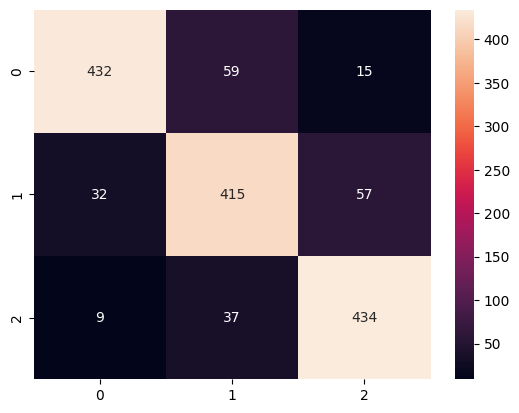

In [ ]:
# Regresion Logistica
calculo_metricas(y_test, pred_rl, 'Regresión Logística')

Reporte de Clasificación - K Vecinos Más Cercanos
              precision    recall  f1-score   support

         1.0       0.99      0.93      0.96       506
         2.0       0.94      0.98      0.96       504
         3.0       0.98      1.00      0.99       480

    accuracy                           0.97      1490
   macro avg       0.97      0.97      0.97      1490
weighted avg       0.97      0.97      0.97      1490



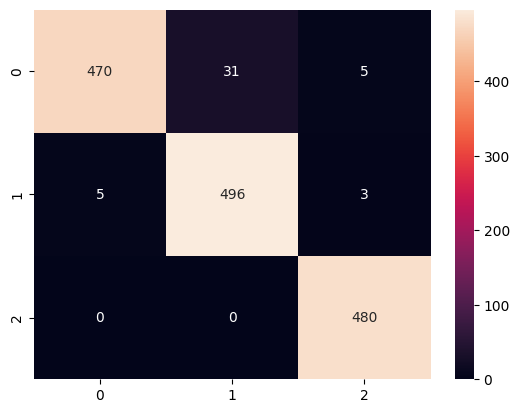

In [ ]:
# K Vecinos Más Cercanos
calculo_metricas(y_test, pred_knn, 'K Vecinos Más Cercanos')

Reporte de Clasificación - Maquina de Soporte Vectorial
              precision    recall  f1-score   support

         1.0       0.99      0.92      0.96       506
         2.0       0.92      0.97      0.94       504
         3.0       0.97      0.98      0.98       480

    accuracy                           0.96      1490
   macro avg       0.96      0.96      0.96      1490
weighted avg       0.96      0.96      0.96      1490



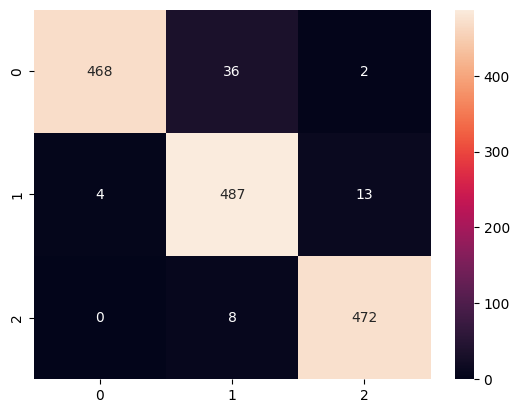

In [ ]:
# Maquina de Soporte Vectorial
calculo_metricas(y_test, pred_svm, 'Maquina de Soporte Vectorial')

Reporte de Clasificación - Árbol de Decisión
              precision    recall  f1-score   support

         1.0       1.00      0.94      0.97       506
         2.0       0.95      0.99      0.97       504
         3.0       0.98      1.00      0.99       480

    accuracy                           0.98      1490
   macro avg       0.98      0.98      0.98      1490
weighted avg       0.98      0.98      0.98      1490



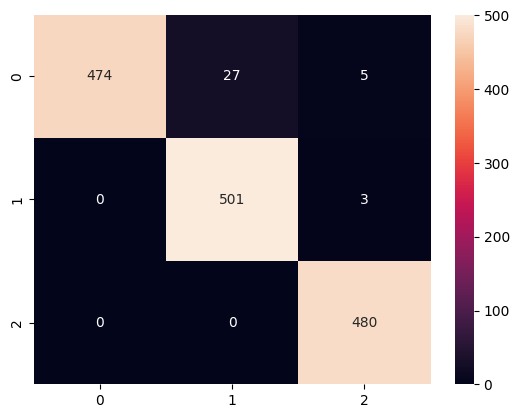

In [ ]:
# Decision Tree
calculo_metricas(y_test, pred_dt, 'Árbol de Decisión')

Reporte de Clasificación - Extra Tree Classifier
              precision    recall  f1-score   support

         1.0       1.00      0.94      0.97       506
         2.0       0.94      0.99      0.97       504
         3.0       0.99      1.00      1.00       480

    accuracy                           0.98      1490
   macro avg       0.98      0.98      0.98      1490
weighted avg       0.98      0.98      0.98      1490



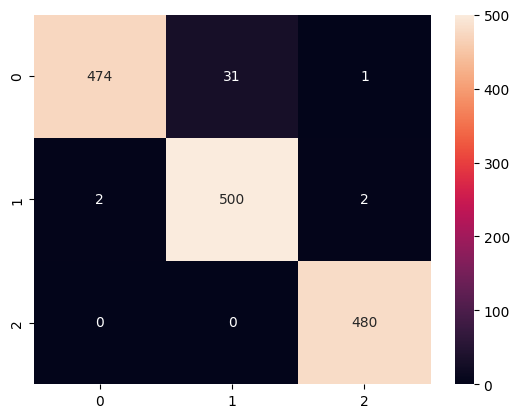

In [ ]:
# Extra Tree Classifier
calculo_metricas(y_test, pred_et, 'Extra Tree Classifier')

Reporte de Clasificación - Random Forest Classifier
              precision    recall  f1-score   support

         1.0       1.00      0.95      0.97       506
         2.0       0.95      0.99      0.97       504
         3.0       0.99      1.00      1.00       480

    accuracy                           0.98      1490
   macro avg       0.98      0.98      0.98      1490
weighted avg       0.98      0.98      0.98      1490



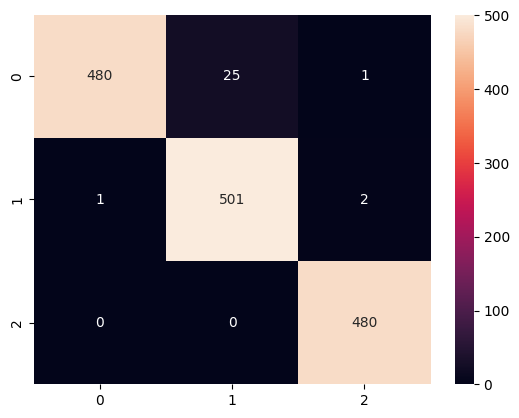

In [ ]:
# Random Forest Classifier
calculo_metricas(y_test, pred_rf, 'Random Forest Classifier')

Reporte de Clasificación - Adaptative Boosting Classifier
              precision    recall  f1-score   support

         1.0       0.86      0.90      0.88       506
         2.0       0.88      0.86      0.87       504
         3.0       0.99      0.96      0.98       480

    accuracy                           0.91      1490
   macro avg       0.91      0.91      0.91      1490
weighted avg       0.91      0.91      0.91      1490



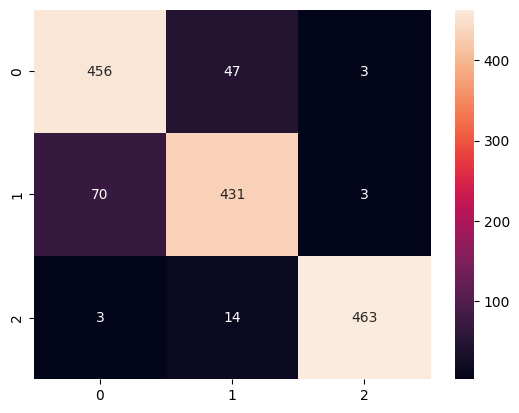

In [ ]:
# Adaptative Boosting Classifier
calculo_metricas(y_test, pred_ab, 'Adaptative Boosting Classifier')

Reporte de Clasificación - Gradient Boosting Classifier
              precision    recall  f1-score   support

         1.0       1.00      0.98      0.99       506
         2.0       0.99      0.99      0.99       504
         3.0       0.99      1.00      1.00       480

    accuracy                           0.99      1490
   macro avg       0.99      0.99      0.99      1490
weighted avg       0.99      0.99      0.99      1490



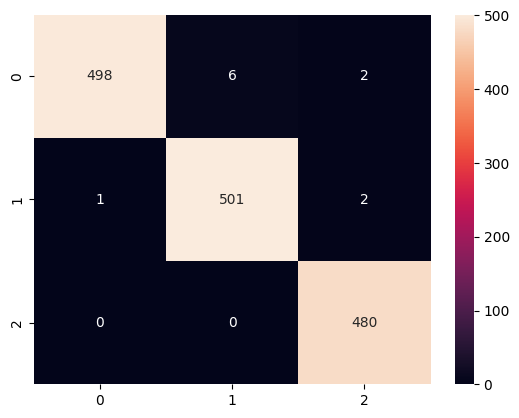

In [ ]:
# Gradient Boosting Classifier
calculo_metricas(y_test, pred_gb, 'Gradient Boosting Classifier')

Reporte de Clasificación - Perceptron Multicapa
              precision    recall  f1-score   support

         1.0       0.98      0.88      0.93       506
         2.0       0.88      0.95      0.91       504
         3.0       0.96      0.98      0.97       480

    accuracy                           0.94      1490
   macro avg       0.94      0.94      0.94      1490
weighted avg       0.94      0.94      0.94      1490



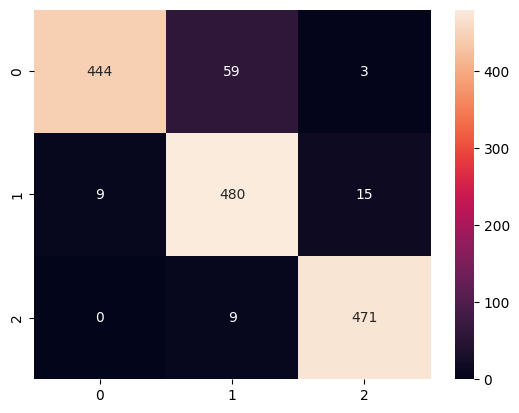

In [ ]:
# Perceptron multicapa
calculo_metricas(y_test, pred_rna, 'Perceptron Multicapa')

# **9. Despliegue del Modelo**
- Construir el Pipeline
- Almacenar el Pipeline en un esquema externo

In [ ]:
data = pd.read_csv('data_clf.csv')
target = 'fetal_health'
X = data.drop(columns=target)
y = data[[target]]

In [ ]:
# Selección de características
ignored = ['fetal_movements', 'severe_decelerations']
all_num = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
all_cat = X.select_dtypes(include=['object']).columns.to_list()
num_features = [col for col in all_num if col not in ignored]
cat_features = [col for col in all_cat if col not in ignored]

In [ ]:
# Imputación de características
from sklearn.impute import SimpleImputer, KNNImputer
num_pipe = Pipeline(steps=[('num_imputer', KNNImputer()), ('scaler', MinMaxScaler())])
num_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('num_imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False

In [ ]:
cat_pipe = Pipeline(steps=[('cat_imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(sparse_output=False))])
cat_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cat_imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputa

In [ ]:
# Se usa el modelo que mejor desempeño tuvo en el f1_score, que no este sobreajustado, de menor complejidad computacional
# y que tenga una matriz de confusión balanceada.
model_gb

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",400
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num', num_pipe, num_features),
                                               ('cat', cat_pipe, cat_features)], remainder='drop')
model = GradientBoostingClassifier(max_depth=9, n_estimators=400, random_state=123)
pipe_model = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
pipe_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=123)
pipe_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
import joblib
joblib.dump(pipe_model, 'fetal_health_model.pkl')


['fetal_health_model.pkl']

In [ ]:
model = joblib.load('fetal_health_model.pkl')
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
model.predict(X_test)

array([1., 1., 1., 1., 3., 1., 2., 1., 1., 1., 1., 2., 1., 1., 2., 1., 1.,
       2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 2., 1., 1., 1., 1., 1., 2., 1., 2., 1., 1., 1., 3., 1.,
       2., 1., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 3., 1., 1., 3., 3., 1., 1.,
       1., 1., 2., 3., 2., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 3., 1., 1.,
       1., 1., 3., 1., 1., 1., 1., 3., 1., 1., 3., 1., 1., 2., 1., 1., 2.,
       2., 2., 2., 1., 1., 1., 1., 1., 2., 2., 1., 2., 1., 1., 1., 1., 1.,
       1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 1., 2., 3., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 1., 2., 1., 2., 3., 1., 1.,
       1., 2., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 1., 1., 1.,
       1., 2., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 2., 1., 1., 1., 1.,
       1., 1., 1., 2., 1.